# DATA 266 Lab 1 — Task 3: CycleGAN Image Style Transfer

Standalone **VS Code / local Jupyter** version.

This notebook implements:
- two generators: Photo → Monet and Monet → Photo
- two PatchGAN discriminators
- adversarial, cycle-consistency, and identity losses
- checkpoint resume
- FID/KID in both directions
- generative precision/recall
- cycle L1, LPIPS, and content cosine similarity
- loss curves and stability metrics
- 30-sample human-audit template
- Kaggle inference artifacts

**Dataset folders expected**
- `task3_gan/data/monet_jpg/`
- `task3_gan/data/photo_jpg/`

Open the `Task3_Standalone` folder as your VS Code workspace, select your Python environment,
and run this notebook from top to bottom.


In [1]:
# Install dependencies once from the VS Code terminal:
# python -m pip install -r requirements.txt
#
# PyTorch/torchvision should be installed separately with the build appropriate
# for your CPU/CUDA system: https://pytorch.org/get-started/locally/

print("Use the VS Code interpreter/kernel where requirements.txt was installed.")


Use the VS Code interpreter/kernel where requirements.txt was installed.


In [40]:
from pathlib import Path
import os, sys, json, math, time, random, logging, platform
from collections import deque

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader

import torchvision.transforms as T
import torchvision.utils as vutils
from torchvision.models import inception_v3, Inception_V3_Weights, resnet18, ResNet18_Weights

from torchmetrics.image.fid import FrechetInceptionDistance
from torchmetrics.image.kid import KernelInceptionDistance
import lpips

from sklearn.metrics import cohen_kappa_score

SEED = 266
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", DEVICE)
if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))

Device: cuda
GPU: NVIDIA GeForce RTX 4090


In [4]:
# ===== VS CODE / LOCAL REPOSITORY SETUP =====
from pathlib import Path
import os

MEMBER_NAME = os.environ.get("DATA266_MEMBER_NAME", "Kavya").strip()
RUN_MODE = os.environ.get("DATA266_RUN_MODE", "full").strip().lower()

if RUN_MODE not in {"smoke", "full"}:
    raise ValueError("DATA266_RUN_MODE must be 'smoke' or 'full'.")

# Optional override:
#   macOS/Linux: export DATA266_REPO_ROOT=/absolute/path/to/Task3_Standalone
#   PowerShell:   $env:DATA266_REPO_ROOT="C:\\path\\to\\Task3_Standalone"
repo_env = os.environ.get("DATA266_REPO_ROOT", "").strip()

if repo_env:
    REPO_ROOT = Path(repo_env).expanduser().resolve()
else:
    # Find the standalone root automatically from the VS Code working directory.
    cwd = Path.cwd().resolve()
    REPO_ROOT = None

    for p in [cwd, *cwd.parents]:
        if (p / "task3_gan").is_dir():
            REPO_ROOT = p
            break
        if p.name == "task3_gan":
            REPO_ROOT = p.parent
            break

    if REPO_ROOT is None:
        raise RuntimeError(
            "Could not locate task3_gan/. Open the Task3_Standalone folder in VS Code "
            "or set DATA266_REPO_ROOT to the Task3_Standalone folder."
        )

TASK_ROOT = REPO_ROOT / "task3_gan"
DATA_ROOT = TASK_ROOT / "data"
MEMBER_DIR = TASK_ROOT / MEMBER_NAME
PART_DIR = MEMBER_DIR
SRC_DIR = MEMBER_DIR / "src"
CKPT_DIR = MEMBER_DIR / "checkpoints"
OUTPUT_DIR = MEMBER_DIR / "outputs"
METRIC_DIR = MEMBER_DIR / "metrics"

# The lab PDF places reproducibility beside task1/task2/task3 at repository root.
MANIFEST_DIR = REPO_ROOT / "reproducibility" / "manifests"
RAW_LOG_DIR = REPO_ROOT / "reproducibility" / "raw_logs"

RUN_CKPT_DIR = CKPT_DIR / RUN_MODE
RUN_OUTPUT_DIR = OUTPUT_DIR if RUN_MODE == "full" else OUTPUT_DIR / "smoke"

A2B_DIR = RUN_OUTPUT_DIR / "pred_A2B"
B2A_DIR = RUN_OUTPUT_DIR / "pred_B2A"
KAGGLE_A2B_DIR = RUN_OUTPUT_DIR / "kaggle_pred_A2B"

RUN_METRIC_DIR = METRIC_DIR if RUN_MODE == "full" else METRIC_DIR / "smoke"
ARTIFACT_BASE = MEMBER_DIR if RUN_MODE == "full" else RUN_OUTPUT_DIR

for d in [
    MEMBER_DIR, SRC_DIR, CKPT_DIR, RUN_CKPT_DIR,
    OUTPUT_DIR, RUN_OUTPUT_DIR, A2B_DIR, B2A_DIR,
    KAGGLE_A2B_DIR, METRIC_DIR, RUN_METRIC_DIR,
    MANIFEST_DIR, RAW_LOG_DIR
]:
    d.mkdir(parents=True, exist_ok=True)

MONET_DIR = DATA_ROOT / "monet_jpg"
PHOTO_DIR = DATA_ROOT / "photo_jpg"

IMAGE_SIZE = 256
BATCH_SIZE = 1
EPOCHS = 30 if RUN_MODE == "full" else 1
LR = 2e-4
BETA1 = 0.5
LAMBDA_CYCLE = 10.0
LAMBDA_ID = 5.0
N_RES_BLOCKS = 6
CHECKPOINT_EVERY = 5

MAX_BATCHES_PER_EPOCH = None if RUN_MODE == "full" else 5
N_EVAL = 200 if RUN_MODE == "full" else 20

# Jupyter + Windows is more reliable with 0 workers.
NUM_WORKERS = 0 if os.name == "nt" else 2

CONFIG = {
    "run_mode": RUN_MODE,
    "seed": SEED,
    "image_size": IMAGE_SIZE,
    "batch_size": BATCH_SIZE,
    "epochs": EPOCHS,
    "lr": LR,
    "beta1": BETA1,
    "lambda_cycle": LAMBDA_CYCLE,
    "lambda_identity": LAMBDA_ID,
    "n_residual_blocks": N_RES_BLOCKS,
    "checkpoint_every": CHECKPOINT_EVERY,
    "max_batches_per_epoch": MAX_BATCHES_PER_EPOCH,
    "eval_samples": N_EVAL,
    "device": str(DEVICE),
}

CONFIG_PATH = (
    MEMBER_DIR / "config.json"
    if RUN_MODE == "full"
    else RUN_OUTPUT_DIR / "config_smoke.json"
)
CONFIG_PATH.write_text(json.dumps(CONFIG, indent=2), encoding="utf-8")

def assert_config_compatible(saved_config, current_config, label="checkpoint"):
    ignored = {"device"}
    keys = sorted((set(saved_config) | set(current_config)) - ignored)
    mismatches = []

    for key in keys:
        if saved_config.get(key) != current_config.get(key):
            mismatches.append(
                f"{key}: saved={saved_config.get(key)!r}, "
                f"current={current_config.get(key)!r}"
            )

    if mismatches:
        details = "\n  - " + "\n  - ".join(mismatches)
        raise RuntimeError(
            f"Refusing to reuse {label}: configuration does not match this run."
            f"{details}\nDelete the incompatible checkpoint or restore the matching configuration."
        )

print("Repository root:", REPO_ROOT)
print("Task root:", TASK_ROOT)
print("Member folder:", MEMBER_DIR)
print("Run mode:", RUN_MODE)
print("Device:", DEVICE)


Repository root: /root/workplace/task3_gan
Task root: /root/workplace/task3_gan/task3_gan
Member folder: /root/workplace/task3_gan/task3_gan/Kavya
Run mode: full
Device: cuda


In [7]:
if not MONET_DIR.exists() or not PHOTO_DIR.exists():
    raise FileNotFoundError(
        "Dataset folders are missing. Put the images here:\n"
        f"  Monet: {MONET_DIR}\n"
        f"  Photos: {PHOTO_DIR}\n"
        "Folder names must be monet_jpg and photo_jpg."
    )

monet_count = len(list(MONET_DIR.glob("*.jpg"))) + len(list(MONET_DIR.glob("*.png")))
photo_count = len(list(PHOTO_DIR.glob("*.jpg"))) + len(list(PHOTO_DIR.glob("*.png")))

if monet_count == 0 or photo_count == 0:
    raise FileNotFoundError(
        "The dataset folders exist but contain no JPG/PNG images. "
        "Copy the Monet and photo dataset into task3_gan/data/."
    )

print("Monet images:", monet_count)
print("Photo images:", photo_count)

Monet images: 300
Photo images: 7038


In [8]:
LOG_PATH = RAW_LOG_DIR / f"{MEMBER_NAME}_task3_{RUN_MODE}.log"
logger = logging.getLogger(f"part3_{RUN_MODE}")
logger.setLevel(logging.INFO)
logger.handlers.clear()
fh = logging.FileHandler(LOG_PATH, mode="a")
sh = logging.StreamHandler(sys.stdout)
fmt = logging.Formatter("%(asctime)s | %(message)s")
fh.setFormatter(fmt); sh.setFormatter(fmt)
logger.addHandler(fh); logger.addHandler(sh)
logger.info("Part 3 run/session started")
logger.info(f"Run mode={RUN_MODE}")
logger.info(f"Python={platform.python_version()} | PyTorch={torch.__version__} | Device={DEVICE}")
if torch.cuda.is_available():
    logger.info(f"GPU={torch.cuda.get_device_name(0)}")

2026-10-03 20:08:35,115 | Part 3 run/session started
2026-10-03 20:08:35,117 | Run mode=full
2026-10-03 20:08:35,118 | Python=3.12.3 | PyTorch=2.14.1+cu130 | Device=cuda
2026-10-03 20:08:35,119 | GPU=NVIDIA GeForce RTX 4090


## 1. Unpaired image dataset
Domain A = photos, Domain B = Monet.

In [9]:
train_tf = T.Compose([
    T.Resize(int(IMAGE_SIZE * 1.12), interpolation=T.InterpolationMode.BICUBIC),
    T.RandomCrop(IMAGE_SIZE),
    T.RandomHorizontalFlip(),
    T.ToTensor(),
    T.Normalize((0.5,0.5,0.5), (0.5,0.5,0.5)),
])

eval_tf = T.Compose([
    T.Resize((IMAGE_SIZE, IMAGE_SIZE), interpolation=T.InterpolationMode.BICUBIC),
    T.ToTensor(),
    T.Normalize((0.5,0.5,0.5), (0.5,0.5,0.5)),
])

def list_images(folder):
    exts = {".jpg", ".jpeg", ".png"}
    return sorted([p for p in folder.iterdir() if p.suffix.lower() in exts])

class UnpairedDataset(Dataset):
    def __init__(self, a_paths, b_paths, transform):
        self.a_paths = a_paths
        self.b_paths = b_paths
        self.transform = transform

    def __len__(self):
        return max(len(self.a_paths), len(self.b_paths))

    def __getitem__(self, idx):
        a_path = self.a_paths[idx % len(self.a_paths)]
        b_path = self.b_paths[random.randrange(len(self.b_paths))]

        a = self.transform(Image.open(a_path).convert("RGB"))
        b = self.transform(Image.open(b_path).convert("RGB"))
        return a, b, str(a_path), str(b_path)

photo_paths = list_images(PHOTO_DIR)
monet_paths = list_images(MONET_DIR)

train_ds = UnpairedDataset(photo_paths, monet_paths, train_tf)
train_loader = DataLoader(
    train_ds, batch_size=BATCH_SIZE, shuffle=True,
    num_workers=NUM_WORKERS, pin_memory=torch.cuda.is_available()
)

print("Photo domain:", len(photo_paths))
print("Monet domain:", len(monet_paths))

Photo domain: 7038
Monet domain: 300


## 2. CycleGAN networks

In [10]:
class ResidualBlock(nn.Module):
    def __init__(self, channels):
        super().__init__()
        self.block = nn.Sequential(
            nn.ReflectionPad2d(1),
            nn.Conv2d(channels, channels, 3),
            nn.InstanceNorm2d(channels),
            nn.ReLU(inplace=True),
            nn.ReflectionPad2d(1),
            nn.Conv2d(channels, channels, 3),
            nn.InstanceNorm2d(channels),
        )

    def forward(self, x):
        return x + self.block(x)


class Generator(nn.Module):
    def __init__(self, n_res=6):
        super().__init__()
        layers = [
            nn.ReflectionPad2d(3),
            nn.Conv2d(3, 64, 7),
            nn.InstanceNorm2d(64),
            nn.ReLU(inplace=True),
        ]

        in_c = 64
        for out_c in [128, 256]:
            layers += [
                nn.Conv2d(in_c, out_c, 3, stride=2, padding=1),
                nn.InstanceNorm2d(out_c),
                nn.ReLU(inplace=True),
            ]
            in_c = out_c

        for _ in range(n_res):
            layers.append(ResidualBlock(in_c))

        for out_c in [128, 64]:
            layers += [
                nn.ConvTranspose2d(in_c, out_c, 3, stride=2, padding=1, output_padding=1),
                nn.InstanceNorm2d(out_c),
                nn.ReLU(inplace=True),
            ]
            in_c = out_c

        layers += [
            nn.ReflectionPad2d(3),
            nn.Conv2d(64, 3, 7),
            nn.Tanh(),
        ]
        self.net = nn.Sequential(*layers)

    def forward(self, x):
        return self.net(x)


class Discriminator(nn.Module):
    def __init__(self):
        super().__init__()
        def block(in_c, out_c, stride=2, norm=True):
            layers = [nn.Conv2d(in_c, out_c, 4, stride=stride, padding=1)]
            if norm:
                layers.append(nn.InstanceNorm2d(out_c))
            layers.append(nn.LeakyReLU(0.2, inplace=True))
            return layers

        self.net = nn.Sequential(
            *block(3, 64, norm=False),
            *block(64, 128),
            *block(128, 256),
            *block(256, 512, stride=1),
            nn.Conv2d(512, 1, 4, padding=1),
        )

    def forward(self, x):
        return self.net(x)


def init_weights(m):
    if isinstance(m, (nn.Conv2d, nn.ConvTranspose2d)):
        nn.init.normal_(m.weight, 0.0, 0.02)
        if m.bias is not None:
            nn.init.zeros_(m.bias)

G_A2B = Generator(N_RES_BLOCKS).to(DEVICE)
G_B2A = Generator(N_RES_BLOCKS).to(DEVICE)
D_A = Discriminator().to(DEVICE)
D_B = Discriminator().to(DEVICE)

for m in [G_A2B, G_B2A, D_A, D_B]:
    m.apply(init_weights)

print("G_A2B params:", sum(p.numel() for p in G_A2B.parameters()))
print("G_B2A params:", sum(p.numel() for p in G_B2A.parameters()))
print("D_A params:", sum(p.numel() for p in D_A.parameters()))
print("D_B params:", sum(p.numel() for p in D_B.parameters()))

G_A2B params: 7837699
G_B2A params: 7837699
D_A params: 2764737
D_B params: 2764737


## 3. Replay buffer

In [11]:
class ReplayBuffer:
    def __init__(self, max_size=50):
        self.max_size = max_size
        self.data = []

    def push_and_pop(self, batch):
        result = []
        for element in batch.detach():
            element = element.unsqueeze(0)
            if len(self.data) < self.max_size:
                self.data.append(element)
                result.append(element)
            elif random.random() > 0.5:
                i = random.randrange(self.max_size)
                old = self.data[i].clone()
                self.data[i] = element
                result.append(old)
            else:
                result.append(element)
        return torch.cat(result, dim=0)

fake_A_buffer = ReplayBuffer()
fake_B_buffer = ReplayBuffer()

### Run mode and training-time check

Default `full` mode uses:
- 30 epochs
- batch size 1
- all available unpaired images
- 200 images per direction for local metrics

With roughly 7,000 photos, one epoch is roughly 7,000 training steps. **Watch the time for epoch 1**.
The training cell prints an estimated total time after each epoch so you can decide whether the
full 30-epoch run is practical on your GPU.

If you change epochs or other training settings after training has started, remove the incompatible
`checkpoints/full/latest_checkpoint.pt` (and old epoch checkpoints) before restarting.

For a quick VS Code test, start the Jupyter kernel with `DATA266_RUN_MODE=smoke`.


## 4. Training

In [12]:
criterion_gan = nn.MSELoss()
criterion_cycle = nn.L1Loss()
criterion_identity = nn.L1Loss()

opt_G = torch.optim.Adam(
    list(G_A2B.parameters()) + list(G_B2A.parameters()), lr=LR, betas=(BETA1, 0.999)
)
opt_D_A = torch.optim.Adam(D_A.parameters(), lr=LR, betas=(BETA1, 0.999))
opt_D_B = torch.optim.Adam(D_B.parameters(), lr=LR, betas=(BETA1, 0.999))

def lr_rule(epoch):
    half = EPOCHS // 2
    if epoch < half:
        return 1.0
    return max(0.0, 1.0 - (epoch - half) / max(1, EPOCHS - half))

sched_G = torch.optim.lr_scheduler.LambdaLR(opt_G, lr_lambda=lr_rule)
sched_D_A = torch.optim.lr_scheduler.LambdaLR(opt_D_A, lr_lambda=lr_rule)
sched_D_B = torch.optim.lr_scheduler.LambdaLR(opt_D_B, lr_lambda=lr_rule)

history = []
nan_count = 0
peak_grad_norm = 0.0
processed_images = 0
start_epoch = 0
cumulative_training_seconds = 0.0
prior_peak_gpu_memory_mb = 0.0
LATEST_CKPT = RUN_CKPT_DIR / "latest_checkpoint.pt"

if LATEST_CKPT.exists():
    ckpt = torch.load(LATEST_CKPT, map_location=DEVICE, weights_only=False)
    assert_config_compatible(ckpt.get("config", {}), CONFIG, label=str(LATEST_CKPT))
    G_A2B.load_state_dict(ckpt["G_A2B"])
    G_B2A.load_state_dict(ckpt["G_B2A"])
    D_A.load_state_dict(ckpt["D_A"])
    D_B.load_state_dict(ckpt["D_B"])
    opt_G.load_state_dict(ckpt["opt_G"])
    opt_D_A.load_state_dict(ckpt["opt_D_A"])
    opt_D_B.load_state_dict(ckpt["opt_D_B"])
    sched_G.load_state_dict(ckpt["sched_G"])
    sched_D_A.load_state_dict(ckpt["sched_D_A"])
    sched_D_B.load_state_dict(ckpt["sched_D_B"])
    history = ckpt.get("history", [])
    nan_count = ckpt.get("nan_count", 0)
    peak_grad_norm = ckpt.get("peak_grad_norm", 0.0)
    processed_images = ckpt.get("processed_images", 0)
    cumulative_training_seconds = ckpt.get("cumulative_training_seconds", 0.0)
    prior_peak_gpu_memory_mb = ckpt.get("peak_gpu_memory_mb", 0.0)
    start_epoch = int(ckpt["epoch"]) + 1
    logger.info(f"Resuming compatible {RUN_MODE} checkpoint from epoch {start_epoch + 1}/{EPOCHS}")

if torch.cuda.is_available():
    torch.cuda.reset_peak_memory_stats()

session_start = time.perf_counter()
for epoch in range(start_epoch, EPOCHS):
    epoch_sums = {"G_total": 0.0, "G_gan": 0.0, "cycle": 0.0, "identity": 0.0,
                  "D_A": 0.0, "D_B": 0.0}
    n_batches = 0
    epoch_start = time.perf_counter()

    for batch_i, (real_A, real_B, _, _) in enumerate(train_loader):
        if MAX_BATCHES_PER_EPOCH is not None and batch_i >= MAX_BATCHES_PER_EPOCH:
            break
        real_A = real_A.to(DEVICE, non_blocking=True)
        real_B = real_B.to(DEVICE, non_blocking=True)
        processed_images += real_A.size(0) + real_B.size(0)

        opt_G.zero_grad(set_to_none=True)
        id_A = G_B2A(real_A)
        id_B = G_A2B(real_B)
        loss_id = (criterion_identity(id_A, real_A) + criterion_identity(id_B, real_B)) * LAMBDA_ID

        fake_B = G_A2B(real_A)
        fake_A = G_B2A(real_B)
        pred_fake_B = D_B(fake_B)
        pred_fake_A = D_A(fake_A)
        loss_gan = (
            criterion_gan(pred_fake_B, torch.ones_like(pred_fake_B)) +
            criterion_gan(pred_fake_A, torch.ones_like(pred_fake_A))
        )

        rec_A = G_B2A(fake_B)
        rec_B = G_A2B(fake_A)
        loss_cycle = (
            criterion_cycle(rec_A, real_A) + criterion_cycle(rec_B, real_B)
        ) * LAMBDA_CYCLE
        loss_G = loss_gan + loss_cycle + loss_id

        if not torch.isfinite(loss_G):
            nan_count += 1
            logger.info(f"Non-finite generator loss at epoch={epoch+1}, batch={batch_i}")
            continue

        loss_G.backward()
        grad_norm = torch.nn.utils.clip_grad_norm_(
            list(G_A2B.parameters()) + list(G_B2A.parameters()), 10.0
        )
        peak_grad_norm = max(peak_grad_norm, float(grad_norm))
        opt_G.step()

        opt_D_A.zero_grad(set_to_none=True)
        pred_real_A = D_A(real_A)
        loss_D_A_real = criterion_gan(pred_real_A, torch.ones_like(pred_real_A))
        fake_A_buf = fake_A_buffer.push_and_pop(fake_A)
        pred_fake_A = D_A(fake_A_buf)
        loss_D_A_fake = criterion_gan(pred_fake_A, torch.zeros_like(pred_fake_A))
        loss_D_A = 0.5 * (loss_D_A_real + loss_D_A_fake)
        loss_D_A.backward()
        opt_D_A.step()

        opt_D_B.zero_grad(set_to_none=True)
        pred_real_B = D_B(real_B)
        loss_D_B_real = criterion_gan(pred_real_B, torch.ones_like(pred_real_B))
        fake_B_buf = fake_B_buffer.push_and_pop(fake_B)
        pred_fake_B = D_B(fake_B_buf)
        loss_D_B_fake = criterion_gan(pred_fake_B, torch.zeros_like(pred_fake_B))
        loss_D_B = 0.5 * (loss_D_B_real + loss_D_B_fake)
        loss_D_B.backward()
        opt_D_B.step()

        epoch_sums["G_total"] += loss_G.item()
        epoch_sums["G_gan"] += loss_gan.item()
        epoch_sums["cycle"] += loss_cycle.item()
        epoch_sums["identity"] += loss_id.item()
        epoch_sums["D_A"] += loss_D_A.item()
        epoch_sums["D_B"] += loss_D_B.item()
        n_batches += 1

    sched_G.step(); sched_D_A.step(); sched_D_B.step()
    elapsed = time.perf_counter() - epoch_start
    row = {"epoch": epoch + 1, "seconds": elapsed}
    for k, v in epoch_sums.items():
        row[k] = v / max(1, n_batches)
    history.append(row)

    logger.info(
        f"epoch={epoch+1}/{EPOCHS} | G={row['G_total']:.4f} | GAN={row['G_gan']:.4f} "
        f"| cycle={row['cycle']:.4f} | id={row['identity']:.4f} "
        f"| D_A={row['D_A']:.4f} | D_B={row['D_B']:.4f}"
    )

    session_elapsed = time.perf_counter() - session_start
    current_peak_mb = torch.cuda.max_memory_allocated() / 1024**2 if torch.cuda.is_available() else 0.0
    ckpt = {
        "epoch": epoch,
        "G_A2B": G_A2B.state_dict(),
        "G_B2A": G_B2A.state_dict(),
        "D_A": D_A.state_dict(),
        "D_B": D_B.state_dict(),
        "opt_G": opt_G.state_dict(),
        "opt_D_A": opt_D_A.state_dict(),
        "opt_D_B": opt_D_B.state_dict(),
        "sched_G": sched_G.state_dict(),
        "sched_D_A": sched_D_A.state_dict(),
        "sched_D_B": sched_D_B.state_dict(),
        "config": CONFIG,
        "history": history,
        "nan_count": nan_count,
        "peak_grad_norm": peak_grad_norm,
        "processed_images": processed_images,
        "cumulative_training_seconds": cumulative_training_seconds + session_elapsed,
        "peak_gpu_memory_mb": max(prior_peak_gpu_memory_mb, current_peak_mb),
    }
    # Keep a resume checkpoint every epoch, but archive only every CHECKPOINT_EVERY epochs
    # (plus the final epoch) to avoid many large optimizer-state files.
    torch.save(ckpt, LATEST_CKPT)

    if (epoch + 1) % CHECKPOINT_EVERY == 0 or (epoch + 1) == EPOCHS:
        torch.save(
            ckpt,
            RUN_CKPT_DIR / f"cyclegan_epoch_{epoch+1:03d}.pt"
        )

    avg_epoch_seconds = (
        sum(float(r["seconds"]) for r in history) / max(1, len(history))
    )
    remaining_epochs = EPOCHS - (epoch + 1)
    eta_seconds = avg_epoch_seconds * remaining_epochs

    logger.info(
        f"epoch_time={elapsed/60:.1f} min | "
        f"estimated_remaining={eta_seconds/3600:.2f} h | "
        f"estimated_total={(avg_epoch_seconds*EPOCHS)/3600:.2f} h"
    )

session_elapsed = time.perf_counter() - session_start
total_training_time = cumulative_training_seconds + session_elapsed
images_per_sec = processed_images / max(total_training_time, 1e-9)
history_df = pd.DataFrame(history)
if history_df.empty:
    raise RuntimeError("No training history is available. Check the checkpoint/run settings.")
history_df.to_csv(RUN_METRIC_DIR / "training_history.csv", index=False)
history_df.tail()

2026-10-03 20:20:59,910 | epoch=1/30 | G=7.0790 | GAN=0.8524 | cycle=4.2544 | id=1.9722 | D_A=0.2388 | D_B=0.2398
2026-10-03 20:21:00,101 | epoch_time=12.2 min | estimated_remaining=5.87 h | estimated_total=6.08 h
2026-10-03 20:33:03,943 | epoch=2/30 | G=5.4641 | GAN=0.8463 | cycle=3.1512 | id=1.4666 | D_A=0.2137 | D_B=0.2158
2026-10-03 20:33:04,205 | epoch_time=12.1 min | estimated_remaining=5.65 h | estimated_total=6.05 h
2026-10-03 20:45:06,951 | epoch=3/30 | G=4.9525 | GAN=0.8632 | cycle=2.7850 | id=1.3043 | D_A=0.2039 | D_B=0.2029
2026-10-03 20:45:07,220 | epoch_time=12.0 min | estimated_remaining=5.44 h | estimated_total=6.04 h
2026-10-03 20:57:19,831 | epoch=4/30 | G=4.7349 | GAN=0.9026 | cycle=2.6061 | id=1.2261 | D_A=0.1905 | D_B=0.1812
2026-10-03 20:57:20,107 | epoch_time=12.2 min | estimated_remaining=5.25 h | estimated_total=6.06 h
2026-10-03 21:09:26,898 | epoch=5/30 | G=4.5050 | GAN=0.9035 | cycle=2.4534 | id=1.1480 | D_A=0.1840 | D_B=0.1816
2026-10-03 21:09:27,319 | epoc

,epoch,seconds,G_total,G_gan,cycle,identity,D_A,D_B
25,26,570.895991,3.206539,1.188126,1.454259,0.564155,0.161360,0.077950
26,27,568.574816,3.184811,1.214037,1.422426,0.548348,0.160107,0.074231
27,28,580.504524,3.150899,1.229801,1.388543,0.532555,0.159323,0.070484
28,29,548.829551,3.132604,1.252127,1.359492,0.520986,0.157841,0.067942
29,30,564.907528,3.109084,1.266525,1.330507,0.512053,0.156174,0.064673


### Compact final model
`generators_final.pt` stores only the two generator weights and config. The larger `latest_checkpoint.pt` is kept for training resume.

In [13]:
# Save a compact weights-only checkpoint for inference/demo.
GENERATORS_FINAL = RUN_CKPT_DIR / "generators_final.pt"

torch.save(
    {
        "G_A2B": G_A2B.state_dict(),
        "G_B2A": G_B2A.state_dict(),
        "config": CONFIG,
    },
    GENERATORS_FINAL,
)

print("Saved compact generator checkpoint:", GENERATORS_FINAL)
print("Use this file for inference/demo when optimizer state is not needed.")


Saved compact generator checkpoint: /root/workplace/task3_gan/task3_gan/Kavya/checkpoints/full/generators_final.pt
Use this file for inference/demo when optimizer state is not needed.


## 5. Loss curves

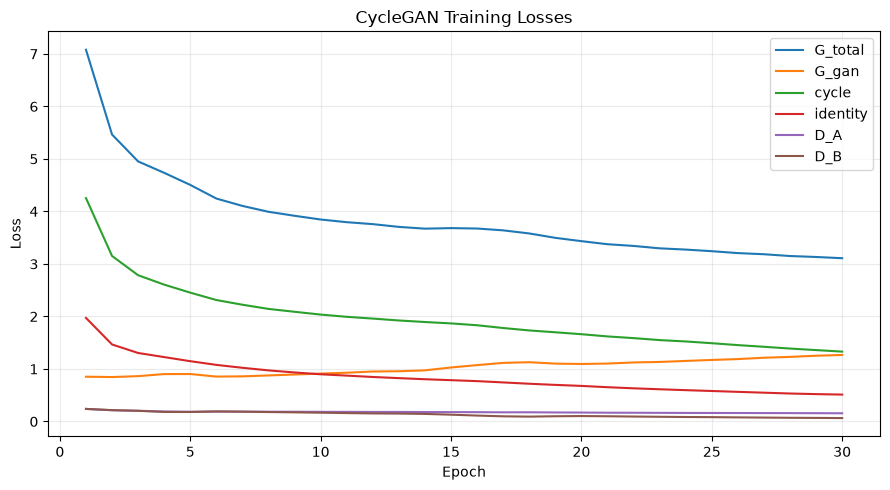

In [14]:
plt.figure(figsize=(9, 5))
for col in ["G_total", "G_gan", "cycle", "identity", "D_A", "D_B"]:
    plt.plot(history_df["epoch"], history_df[col], label=col)
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("CycleGAN Training Losses")
plt.legend()
plt.grid(alpha=0.25)
plt.tight_layout()
plt.savefig(RUN_METRIC_DIR / "loss_curves.png", dpi=160)
plt.show()

## 6. Generate translations in both directions

In [46]:
@torch.no_grad()
def load_eval_tensor(path):
    return eval_tf(Image.open(path).convert("RGB")).unsqueeze(0).to(DEVICE)

@torch.no_grad()
def save_translation(model, input_paths, out_dir, prefix):
    model.eval()
    saved = []
    for i, path in enumerate(input_paths):
        x = load_eval_tensor(path)
        y = model(x)
        y01 = (y.clamp(-1, 1) + 1) / 2
        out_path = out_dir / f"{prefix}_{i:05d}.jpg"
        vutils.save_image(y01, out_path)
        saved.append(out_path)
    return saved

eval_photo_paths = photo_paths[:min(N_EVAL, len(photo_paths))]
eval_monet_paths = monet_paths[:min(N_EVAL, len(monet_paths))]

saved_A2B = save_translation(G_A2B, eval_photo_paths, A2B_DIR, "photo_to_monet")
saved_B2A = save_translation(G_B2A, eval_monet_paths, B2A_DIR, "monet_to_photo")

print("A->B generated:", len(saved_A2B))
print("B->A generated:", len(saved_B2A))

A->B generated: 200
B->A generated: 200


## 7. FID and KID in both directions

Local FID/KID use at most `N_EVAL` images per direction (200 in full mode). This is a relatively
small sample, so treat these as **local comparison metrics**, not as directly comparable to a
competition MiFID/FID score computed on a different sample size or protocol.

The pretrained Inception network used by TorchMetrics is evaluation-only and does not generate images.


In [45]:
%pip install -q torch-fidelity lpips

# torchmetrics checked for torch-fidelity when it was first imported,
# so reload those modules to make it notice the new package.
import importlib
import torchmetrics.utilities.imports as tm_imports
import torchmetrics.image.fid as tm_fid
import torchmetrics.image.kid as tm_kid
importlib.reload(tm_imports)
importlib.reload(tm_fid)
importlib.reload(tm_kid)
from torchmetrics.image.fid import FrechetInceptionDistance
from torchmetrics.image.kid import KernelInceptionDistance

Note: you may need to restart the kernel to use updated packages.


In [47]:
def image_to_uint8(path):
    img = T.Resize((299,299))(Image.open(path).convert("RGB"))
    x = T.PILToTensor()(img)  # uint8 [0,255]
    return x

def fid_kid(real_paths, fake_paths):
    fid = FrechetInceptionDistance(feature=2048, normalize=False).to(DEVICE)
    kid = KernelInceptionDistance(subset_size=min(50, len(fake_paths)), normalize=False).to(DEVICE)

    n = min(len(real_paths), len(fake_paths), N_EVAL)
    for i in range(n):
        real = image_to_uint8(real_paths[i]).unsqueeze(0).to(DEVICE)
        fake = image_to_uint8(fake_paths[i]).unsqueeze(0).to(DEVICE)
        fid.update(real, real=True); fid.update(fake, real=False)
        kid.update(real, real=True); kid.update(fake, real=False)

    fid_value = float(fid.compute().cpu())
    kid_mean, kid_std = kid.compute()
    return fid_value, float(kid_mean.cpu()), float(kid_std.cpu())

fid_A2B, kid_A2B, kid_A2B_std = fid_kid(eval_monet_paths, saved_A2B)
fid_B2A, kid_B2A, kid_B2A_std = fid_kid(eval_photo_paths, saved_B2A)

print("A->B FID:", fid_A2B, "KID:", kid_A2B)
print("B->A FID:", fid_B2A, "KID:", kid_B2A)

/usr/local/lib/python3.12/dist-packages/torchmetrics/utilities/prints.py:43: UserWarning: Metric `Kernel Inception Distance` will save all extracted features in buffer. For large datasets this may lead to large memory footprint.
  warnings.warn(*args, **kwargs)


A->B FID: 109.37059783935547 KID: 0.008049611933529377
B->A FID: 112.7646484375 KID: 0.01993686333298683


## 8. LPIPS, cycle-reconstruction L1, and content cosine similarity

- **Cycle L1** compares the input image with its cycle reconstruction.
- **LPIPS in this notebook also compares input vs. cycle reconstruction**, not input vs. direct translation.
- **Content cosine similarity** compares the input with the direct translation using ResNet features.

The pretrained AlexNet/ResNet feature networks below are used only for evaluation. They are not
part of either generator or discriminator and are not used to create the Kaggle inference images.


In [48]:
lpips_fn = lpips.LPIPS(net="alex").to(DEVICE).eval()

resnet = resnet18(weights=ResNet18_Weights.DEFAULT)
resnet.fc = nn.Identity()
resnet = resnet.to(DEVICE).eval()

resnet_pre = T.Compose([
    T.Resize((224,224)),
    T.Normalize(
        mean=ResNet18_Weights.DEFAULT.transforms().mean,
        std=ResNet18_Weights.DEFAULT.transforms().std,
    ),
])

@torch.no_grad()
def eval_reconstruction_and_content(input_paths, G_forward, G_backward):
    cycle_l1 = []
    lpips_vals = []
    content_cos = []

    for path in input_paths[:N_EVAL]:
        x = load_eval_tensor(path)
        fake = G_forward(x)
        rec = G_backward(fake)

        cycle_l1.append(F.l1_loss(rec, x).item())
        lpips_vals.append(float(lpips_fn(x, rec).mean().cpu()))

        x01 = (x + 1) / 2
        f01 = (fake + 1) / 2

        fx = resnet(resnet_pre(x01))
        ff = resnet(resnet_pre(f01))
        content_cos.append(float(F.cosine_similarity(fx, ff, dim=1).mean().cpu()))

    return {
        "cycle_l1": float(np.mean(cycle_l1)),
        "lpips_cycle": float(np.mean(lpips_vals)),
        "content_cosine": float(np.mean(content_cos)),
    }

extra_A2B = eval_reconstruction_and_content(eval_photo_paths, G_A2B, G_B2A)
extra_B2A = eval_reconstruction_and_content(eval_monet_paths, G_B2A, G_A2B)

print("A->B:", extra_A2B)
print("B->A:", extra_B2A)

Setting up [LPIPS] perceptual loss: trunk [alex], v[0.1], spatial [off]


/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:207: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:222: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=AlexNet_Weights.IMAGENET1K_V1`. You can also use `weights=AlexNet_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Loading model from: /usr/local/lib/python3.12/dist-packages/lpips/weights/v0.1/alex.pth
A->B: {'cycle_l1': 0.08145898470655083, 'lpips_cycle': 0.16782538767904043, 'content_cosine': 0.7915976110100746}
B->A: {'cycle_l1': 0.06682148974388838, 'lpips_cycle': 0.22153827030211687, 'content_cosine': 0.8403003630042076}


## 9. Generative precision and recall approximation

This uses Inception-v3 features and the k-nearest-neighbor manifold method.
Higher precision means generated samples tend to lie near the real target manifold.
Higher recall means generated samples cover more of the real target manifold.

In [49]:
inception = inception_v3(weights=Inception_V3_Weights.DEFAULT, aux_logits=True)
inception.fc = nn.Identity()
inception = inception.to(DEVICE).eval()

inc_pre = T.Compose([
    T.Resize((299,299)),
    T.Normalize(
        mean=Inception_V3_Weights.DEFAULT.transforms().mean,
        std=Inception_V3_Weights.DEFAULT.transforms().std,
    ),
])

@torch.no_grad()
def inception_features(paths):
    feats = []
    for path in paths[:N_EVAL]:
        img = T.ToTensor()(Image.open(path).convert("RGB")).unsqueeze(0).to(DEVICE)
        f = inception(inc_pre(img))
        feats.append(f.squeeze(0).cpu())
    return torch.stack(feats)

def manifold_radii(features, k=3):
    d = torch.cdist(features, features)
    d.fill_diagonal_(float("inf"))
    kth = torch.topk(d, k=k, largest=False, dim=1).values[:, -1]
    return kth

def generative_precision_recall(real_f, fake_f, k=3):
    real_r = manifold_radii(real_f, k)
    fake_r = manifold_radii(fake_f, k)

    d_fake_real = torch.cdist(fake_f, real_f)
    precision = (d_fake_real <= real_r.unsqueeze(0)).any(dim=1).float().mean().item()

    d_real_fake = d_fake_real.T
    recall = (d_real_fake <= fake_r.unsqueeze(0)).any(dim=1).float().mean().item()
    return precision, recall

real_B_feat = inception_features(eval_monet_paths)
fake_B_feat = inception_features(saved_A2B)
prec_A2B, rec_A2B = generative_precision_recall(real_B_feat, fake_B_feat, k=3)

real_A_feat = inception_features(eval_photo_paths)
fake_A_feat = inception_features(saved_B2A)
prec_B2A, rec_B2A = generative_precision_recall(real_A_feat, fake_A_feat, k=3)

print("A->B precision/recall:", prec_A2B, rec_A2B)
print("B->A precision/recall:", prec_B2A, rec_B2A)

A->B precision/recall: 0.5199999809265137 0.5849999785423279
B->A precision/recall: 0.7200000286102295 0.39500001072883606


## 10. Human audit sheet — 30 fixed samples, 2 raters

Both raters should score the **same fixed 30 translated samples** for:
- style
- content preservation
- artifacts

Use a 1–5 ordinal scale. To keep the audit blinded, present anonymized/mixed filenames so raters
do not know whose model generated each image.

After both raters fill the CSV, rerun:
1. the audit metric cell,
2. the final metrics cell,
3. the `results.md` cell.

This notebook reports:
- mean human score per dimension,
- exact percent agreement,
- quadratic-weighted Cohen's kappa.


In [50]:
# Team-shared fixed list. The first run creates it from the same sorted photo-domain inputs;
# every member then reuses exactly that list from task3_gan/data/.
SHARED_AUDIT_LIST = DATA_ROOT / "human_audit_fixed_30.txt"

def get_shared_audit_source_names():
    if SHARED_AUDIT_LIST.exists():
        names = [x.strip() for x in SHARED_AUDIT_LIST.read_text(encoding="utf-8").splitlines() if x.strip()]
        if len(names) != 30:
            raise RuntimeError(f"{SHARED_AUDIT_LIST} exists but does not contain exactly 30 filenames.")
        return names

    if RUN_MODE != "full":
        # Smoke test does not establish the team's official audit list.
        return [p.name for p in eval_photo_paths[:min(30, len(eval_photo_paths))]]

    if len(eval_photo_paths) < 30:
        raise RuntimeError("Need at least 30 evaluation photos for the human audit.")
    rng = np.random.default_rng(SEED)
    chosen = sorted(rng.choice(len(eval_photo_paths), size=30, replace=False).tolist())
    names = [eval_photo_paths[i].name for i in chosen]
    SHARED_AUDIT_LIST.write_text("\n".join(names) + "\n", encoding="utf-8")
    print("Created team-shared audit list:", SHARED_AUDIT_LIST)
    return names

audit_source_names = get_shared_audit_source_names()
source_to_generated = {
    src.name: saved_A2B[i].name
    for i, src in enumerate(eval_photo_paths[:len(saved_A2B)])
}
missing = [name for name in audit_source_names if name not in source_to_generated]
if missing and RUN_MODE == "full":
    raise RuntimeError(
        "Some shared audit inputs were not included in N_EVAL. Increase N_EVAL. Missing: " + str(missing[:5])
    )

audit_rows = []
for i, source_name in enumerate(audit_source_names, 1):
    generated_name = source_to_generated.get(source_name, "")
    audit_rows.append({
        "sample_id": i,
        "source_photo_filename": source_name,
        "generated_filename": generated_name,
        "rater1_style": np.nan,
        "rater1_content": np.nan,
        "rater1_artifacts": np.nan,
        "rater2_style": np.nan,
        "rater2_content": np.nan,
        "rater2_artifacts": np.nan,
    })

audit_template = pd.DataFrame(audit_rows)
AUDIT_PATH = ARTIFACT_BASE / "human_audit_30.csv"

# Preserve completed rater scores on reruns when the fixed sample list is unchanged.
if AUDIT_PATH.exists():
    existing_audit = pd.read_csv(AUDIT_PATH)
    key_cols = ["sample_id", "source_photo_filename", "generated_filename"]
    if (len(existing_audit) == len(audit_template) and
        all(col in existing_audit.columns for col in key_cols) and
        existing_audit[key_cols].fillna("").astype(str).equals(
            audit_template[key_cols].fillna("").astype(str)
        )):
        audit_df = existing_audit
        print("Preserving existing human-audit ratings:", AUDIT_PATH)
    else:
        raise RuntimeError(
            "Existing human_audit_30.csv does not match the team's fixed 30 samples. "
            "Resolve the shared audit list intentionally instead of overwriting ratings."
        )
else:
    audit_df = audit_template
    audit_df.to_csv(AUDIT_PATH, index=False)
    print("Created human-audit sheet:", AUDIT_PATH)

audit_df.head()

Preserving existing human-audit ratings: /root/workplace/task3_gan/task3_gan/Kavya/human_audit_30.csv


,sample_id,source_photo_filename,generated_filename,rater1_style,rater1_content,rater1_artifacts,rater2_style,rater2_content,rater2_artifacts
0,1,0080f94ebc.jpg,photo_to_monet_00011.jpg,NaN,NaN,NaN,NaN,NaN,NaN
1,2,009ddaed1f.jpg,photo_to_monet_00014.jpg,NaN,NaN,NaN,NaN,NaN,NaN
2,3,00aeb60e25.jpg,photo_to_monet_00015.jpg,NaN,NaN,NaN,NaN,NaN,NaN
3,4,01622039ef.jpg,photo_to_monet_00030.jpg,NaN,NaN,NaN,NaN,NaN,NaN
4,5,01771d99c3.jpg,photo_to_monet_00035.jpg,NaN,NaN,NaN,NaN,NaN,NaN


In [51]:
# Run this after both raters fill the CSV.
audit = pd.read_csv(AUDIT_PATH)

agreement = {}

for dimension in ["style", "content", "artifacts"]:
    a = pd.to_numeric(audit[f"rater1_{dimension}"], errors="coerce")
    b = pd.to_numeric(audit[f"rater2_{dimension}"], errors="coerce")
    mask = a.notna() & b.notna()

    if mask.sum() >= 2:
        combined = pd.concat([a[mask], b[mask]], ignore_index=True)

        agreement[f"{dimension}_mean_score"] = float(combined.mean())
        agreement[f"{dimension}_percent_agreement"] = float(
            (a[mask] == b[mask]).mean()
        )
        agreement[f"{dimension}_quadratic_kappa"] = float(
            cohen_kappa_score(
                a[mask].astype(int),
                b[mask].astype(int),
                weights="quadratic",
            )
        )

agreement


{}

## 11. Final metrics file

In [52]:
total_params = sum(
    p.numel() for m in [G_A2B, G_B2A, D_A, D_B] for p in m.parameters()
)
current_peak_mb = torch.cuda.max_memory_allocated() / 1024**2 if torch.cuda.is_available() else 0.0
metrics = {
    "fid_A2B": fid_A2B,
    "kid_A2B": kid_A2B,
    "kid_A2B_std": kid_A2B_std,
    "generative_precision_A2B": prec_A2B,
    "generative_recall_A2B": rec_A2B,
    "cycle_l1_A2B": extra_A2B["cycle_l1"],
    "lpips_A2B": extra_A2B["lpips_cycle"],
    "content_cosine_A2B": extra_A2B["content_cosine"],
    "fid_B2A": fid_B2A,
    "kid_B2A": kid_B2A,
    "kid_B2A_std": kid_B2A_std,
    "generative_precision_B2A": prec_B2A,
    "generative_recall_B2A": rec_B2A,
    "cycle_l1_B2A": extra_B2A["cycle_l1"],
    "lpips_B2A": extra_B2A["lpips_cycle"],
    "content_cosine_B2A": extra_B2A["content_cosine"],
    "final_generator_total_loss": float(history_df.iloc[-1]["G_total"]),
    "final_cycle_loss": float(history_df.iloc[-1]["cycle"]),
    "final_identity_loss": float(history_df.iloc[-1]["identity"]),
    "final_D_A_loss": float(history_df.iloc[-1]["D_A"]),
    "final_D_B_loss": float(history_df.iloc[-1]["D_B"]),
    "peak_gradient_norm": peak_grad_norm,
    "nan_count": nan_count,
    "parameter_count_total": total_params,
    "training_time_seconds": total_training_time,
    "images_per_sec": images_per_sec,
    "peak_gpu_memory_mb": max(prior_peak_gpu_memory_mb, current_peak_mb),
    "device": torch.cuda.get_device_name(0) if torch.cuda.is_available() else "CPU",
    "run_mode": RUN_MODE,
}
metrics.update(agreement)
metrics_df = pd.DataFrame([metrics])
metrics_df.to_csv(ARTIFACT_BASE / "metrics_report.csv", index=False)
metrics_df.to_csv(ARTIFACT_BASE / "full_metrics_report.csv", index=False)
print("Saved full metrics report:", ARTIFACT_BASE / "full_metrics_report.csv")
metrics_df.T

Saved full metrics report: /root/workplace/task3_gan/task3_gan/Kavya/full_metrics_report.csv


,0
fid_A2B,109.370598
kid_A2B,0.00805
kid_A2B_std,0.002692
generative_precision_A2B,0.52
generative_recall_A2B,0.585
cycle_l1_A2B,0.081459
lpips_A2B,0.167825
content_cosine_A2B,0.791598
fid_B2A,112.764648
kid_B2A,0.019937


In [59]:

# Save environment/package manifest for reproducibility.
import subprocess
manifest_path = MANIFEST_DIR / f"{MEMBER_NAME}_task3_manifest.txt"

with open(manifest_path, "w", encoding="utf-8") as f:
    f.write(f"Python: {platform.python_version()}\n")
    f.write(f"PyTorch: {torch.__version__}\n")
    f.write(f"Device: {DEVICE}\n")
    if torch.cuda.is_available():
        f.write(f"GPU: {torch.cuda.get_device_name(0)}\n")
    f.write("\n--- pip freeze ---\n")
    try:
        freeze = subprocess.check_output(
            [sys.executable, "-m", "pip", "freeze"], text=True
        )
        f.write(freeze)
    except Exception as e:
        f.write(f"Could not capture pip freeze: {e}\n")

print("Saved manifest:", manifest_path)


Saved manifest: /root/workplace/task3_gan/reproducibility/manifests/Kavya_task3_manifest.txt
